In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [4]:
listings = pd.read_csv("../../../Data/cleaned/Listings_Clean.csv")
listings_fe = listings.copy()

C:\Users\Parv Gupta\AppData\Local\Temp\ipykernel_12568\2621071453.py:1: DtypeWarning: Columns (5,8,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  listings = pd.read_csv("../../../Data/cleaned/Listings_Clean.csv")


# KPI 1 - HostTrust Score

## Candidate Variable Validation

Before constructing the HostTrust Score, each potential variable must be evaluated to determine whether it meaningfully contributes to host reliability.

Instead of assigning arbitrary weights, this project adopts a data-driven approach where every candidate variable is first validated against guest satisfaction.

The objective is to identify which host characteristics have the strongest relationship with guest ratings before incorporating them into the final KPI.

The candidate variables considered are:

- Superhost Status
- Host Response Rate
- Host Response Time
- Host Acceptance Rate
- Identity Verification
- Host Experience

Each variable will be evaluated individually before the HostTrust Score is formulated.

## Valdiation 1- Superhost or Not

In [5]:
listings_fe["host_is_superhost"].value_counts()

host_is_superhost
False    229185
True      50249
Name: count, dtype: int64

In [6]:
listings_fe.groupby("host_is_superhost")["review_scores_rating"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
host_is_superhost,,,,
False,142730,92.261410,95.0,11.096962
True,45469,96.996437,98.0,4.029591


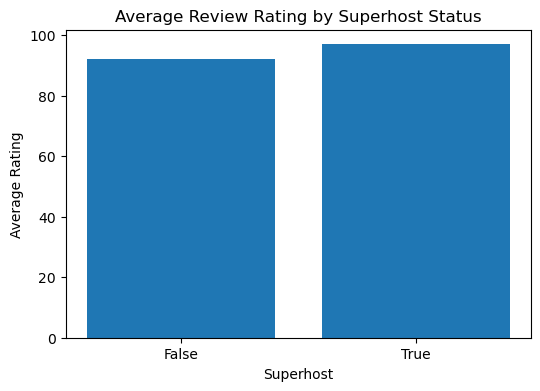

In [7]:
import matplotlib.pyplot as plt

superhost_rating = (
    listings_fe.groupby("host_is_superhost")["review_scores_rating"]
    .mean()
)

plt.figure(figsize=(6,4))
plt.bar(
    superhost_rating.index.astype(str),
    superhost_rating.values
)

plt.title("Average Review Rating by Superhost Status")
plt.xlabel("Superhost")
plt.ylabel("Average Rating")

plt.show()

<Figure size 600x500 with 0 Axes>

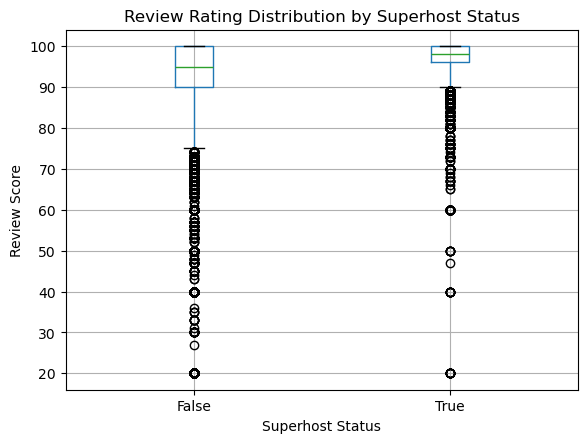

In [8]:
plt.figure(figsize=(6,5))

listings_fe.boxplot(
    column="review_scores_rating",
    by="host_is_superhost"
)

plt.title("Review Rating Distribution by Superhost Status")
plt.suptitle("")  # Removes automatic title
plt.xlabel("Superhost Status")
plt.ylabel("Review Score")

plt.show()

| Variable | Superhost Status |
|----------|------------------|
| Business Relevance | High |
| Evidence Strength | Strong positive relationship with guest ratings and significantly lower rating variability, indicating consistently better guest experiences. |
| Data Reliability | High – Reliable binary feature with no significant quality concerns after data cleaning. |
| Improvement Potential | Medium – Hosts can achieve Superhost status by consistently meeting Airbnb's performance standards. |
| Expected Influence on HostTrust | High |

## Validation 2 – Host Response Rate

In [9]:
listings_fe["host_response_rate"].describe()

count    150898.000000
mean          0.865912
std           0.283768
min           0.000000
25%           0.900000
50%           1.000000
75%           1.000000
max           1.000000
Name: host_response_rate, dtype: float64

In [10]:
listings_fe[
    ["host_response_rate", "review_scores_rating"]
].corr()

,host_response_rate,review_scores_rating
host_response_rate,1.000000,0.112409
review_scores_rating,0.112409,1.000000


In [11]:
listings_fe["host_response_rate_pct"] = (
    listings_fe["host_response_rate"] * 100
)

C:\Users\Parv Gupta\AppData\Local\Temp\ipykernel_12568\3436638526.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("response_rate_group")["review_scores_rating"]


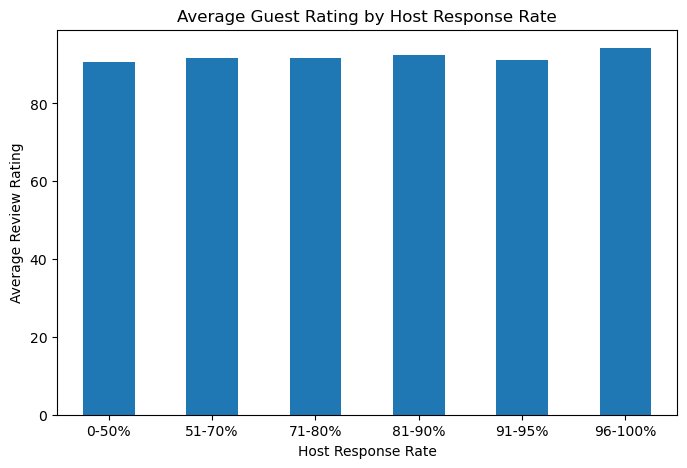

In [12]:
bins = [0, 50, 70, 80, 90, 95, 100]

labels = [
    "0-50%",
    "51-70%",
    "71-80%",
    "81-90%",
    "91-95%",
    "96-100%"
]

listings_fe["response_rate_group"] = pd.cut(
    listings_fe["host_response_rate_pct"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

response_analysis = (
    listings_fe
    .groupby("response_rate_group")["review_scores_rating"]
    .mean()
)

response_analysis.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Guest Rating by Host Response Rate")
plt.xlabel("Host Response Rate")
plt.ylabel("Average Review Rating")
plt.xticks(rotation=0)

plt.show()

| Variable                        | Host Response Rate |
| ------------------------------- | ------------------ |
| Business Relevance              | High               |
| Evidence Strength               | Moderate           |
| Data Reliability                | High               |
| Improvement Potential           | High               |
| Expected Influence on HostTrust | Medium–Low       |


In [13]:
## Validation 3: Responsiveness


In [14]:
listings_fe["host_response_time"].value_counts(dropna=False)

host_response_time
NaN                   128701
within an hour         83434
within a few hours     28891
within a day           23423
a few days or more     15150
Name: count, dtype: int64

In [15]:
response_time_analysis = (
    listings_fe
    .groupby("host_response_time")["review_scores_rating"]
    .agg(["count","mean","median","std"])
)

response_time_analysis

,count,mean,median,std
host_response_time,,,,
a few days or more,7966,90.424429,95.0,14.985827
within a day,16124,93.513520,96.0,9.862825
within a few hours,21209,93.906879,97.0,9.093948
within an hour,65785,93.804804,96.0,8.891245


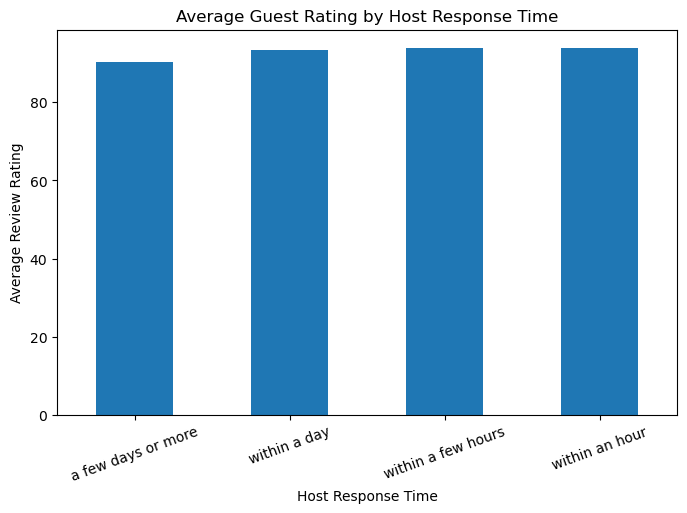

In [16]:
response_time_analysis["mean"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Guest Rating by Host Response Time")
plt.xlabel("Host Response Time")
plt.ylabel("Average Review Rating")
plt.xticks(rotation=20)

plt.show()

| Variable                        | Host Response Time |
| ------------------------------- | ------------------ |
| Business Relevance              | High               |
| Observed Impact                 | Moderate–Strong    |
| Data Reliability                | High               |
| Improvement Potential           | High               |
| Expected Influence on HostTrust | Medium             |


## Validation 4: Host Acceptance Rate

In [17]:
listings_fe["host_acceptance_rate"].describe()

count    166577.000000
mean          0.827123
std           0.289231
min           0.000000
25%           0.780000
50%           0.980000
75%           1.000000
max           1.000000
Name: host_acceptance_rate, dtype: float64

In [18]:
listings_fe[
    ["host_acceptance_rate", "review_scores_rating"]
].corr()

,host_acceptance_rate,review_scores_rating
host_acceptance_rate,1.000000,-0.017294
review_scores_rating,-0.017294,1.000000


In [19]:
listings_fe["acceptance_rate_pct"] = (
    listings_fe["host_acceptance_rate"] * 100
)

bins = [0, 50, 70, 80, 90, 95, 100]

labels = [
    "0-50%",
    "51-70%",
    "71-80%",
    "81-90%",
    "91-95%",
    "96-100%"
]

listings_fe["acceptance_rate_group"] = pd.cut(
    listings_fe["acceptance_rate_pct"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

acceptance_analysis = (
    listings_fe
    .groupby("acceptance_rate_group")["review_scores_rating"]
    .agg(["count","mean","median","std"])
)

acceptance_analysis

C:\Users\Parv Gupta\AppData\Local\Temp\ipykernel_12568\2264260229.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("acceptance_rate_group")["review_scores_rating"]


,count,mean,median,std
acceptance_rate_group,,,,
0-50%,16165,94.047324,97.0,9.635644
51-70%,7113,93.920427,97.0,9.618547
71-80%,7400,93.921216,97.0,9.254734
81-90%,11060,93.514557,96.0,9.190190
91-95%,10311,93.095141,96.0,9.641718
96-100%,76946,93.580537,96.0,9.458687


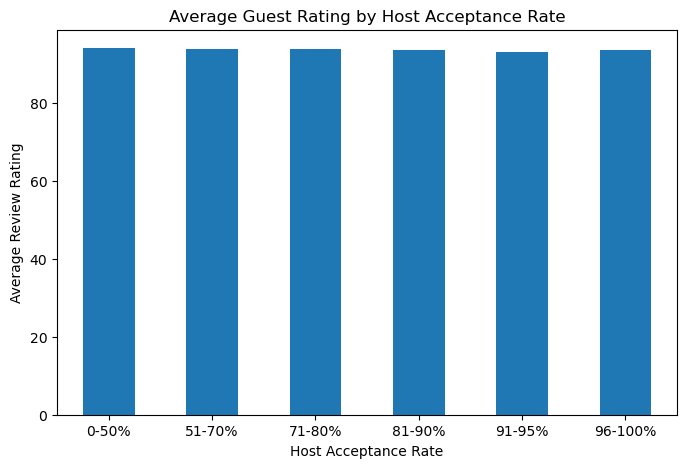

In [20]:
acceptance_analysis["mean"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Guest Rating by Host Acceptance Rate")
plt.xlabel("Host Acceptance Rate")
plt.ylabel("Average Review Rating")
plt.xticks(rotation=0)

plt.show()

| Variable                        | Host Acceptance Rate |
| ------------------------------- | -------------------- |
| Business Relevance              | Medium               |
| Observed Impact                 | Weak                 |
| Data Reliability                | High                 |
| Improvement Potential           | Medium               |
| Expected Influence on HostTrust | Low                  |


## Validation 5: Identity Verification


In [21]:
listings_fe["host_identity_verified"].value_counts(dropna=False)

host_identity_verified
True     201098
False     78336
NaN         165
Name: count, dtype: int64

In [22]:
identity_analysis = (
    listings_fe
    .groupby("host_identity_verified")["review_scores_rating"]
    .agg(["count", "mean", "median", "std"])
)

identity_analysis

,count,mean,median,std
host_identity_verified,,,,
False,41595,92.464238,97.0,12.413104
True,146604,93.672424,96.0,9.282174


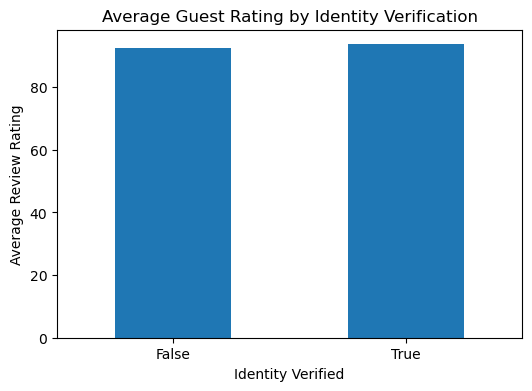

In [23]:
identity_analysis["mean"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Average Guest Rating by Identity Verification")
plt.xlabel("Identity Verified")
plt.ylabel("Average Review Rating")
plt.xticks(rotation=0)

plt.show()

| Variable                        | Host Identity Verified |
| ------------------------------- | ---------------------- |
| Business Relevance              | High                   |
| Observed Impact                 | Moderate               |
| Data Reliability                | High                   |
| Improvement Potential           | Low                    |
| Expected Influence on HostTrust | Medium                 |


## Validation 6: Host Experience


In [24]:
listings_fe["host_since"] = pd.to_datetime(listings_fe["host_since"])

today = pd.Timestamp.today()

listings_fe["host_experience_years"] = (
    (today - listings_fe["host_since"]).dt.days / 365.25
)

In [25]:
listings_fe["host_experience_years"].describe()

count    279434.000000
mean         10.225911
std           2.436356
min           5.347023
25%           8.232717
50%          10.381930
75%          12.008214
max          17.889117
Name: host_experience_years, dtype: float64

In [26]:
bins = [5, 7, 9, 11, 13, 18]

labels = [
    "5-7 Years",
    "7-9 Years",
    "9-11 Years",
    "11-13 Years",
    "13+ Years"
]

listings_fe["experience_group"] = pd.cut(
    listings_fe["host_experience_years"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
experience_analysis = (
    listings_fe
    .groupby("experience_group")["review_scores_rating"]
    .agg(["count", "mean", "median", "std"])
)

experience_analysis

C:\Users\Parv Gupta\AppData\Local\Temp\ipykernel_12568\1706228370.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("experience_group")["review_scores_rating"]


,count,mean,median,std
experience_group,,,,
5-7 Years,16420,91.212058,97.0,14.643294
7-9 Years,35655,92.505932,96.0,11.821920
9-11 Years,54302,93.726401,97.0,9.570907
11-13 Years,53227,94.003833,96.0,8.327072
13+ Years,28595,94.062878,96.0,7.877083


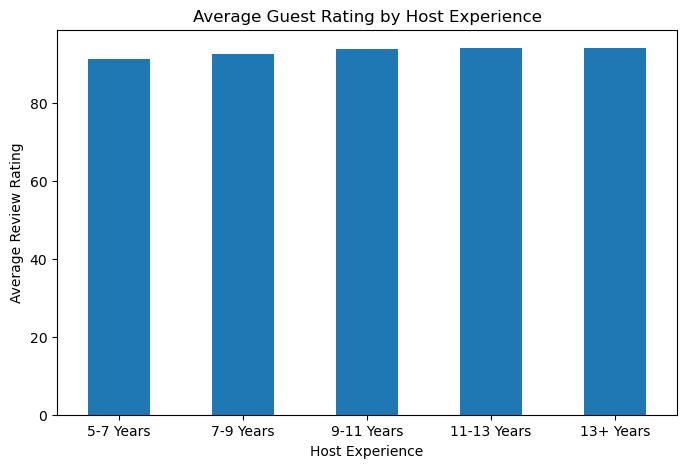

In [27]:
experience_analysis["mean"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Guest Rating by Host Experience")
plt.xlabel("Host Experience")
plt.ylabel("Average Review Rating")
plt.xticks(rotation=0)

plt.show()

| Variable                        | Host Experience |
| ------------------------------- | --------------- |
| Business Relevance              | High            |
| Observed Impact                 | Strong          |
| Data Reliability                | High            |
| Improvement Potential           | Low             |
| Expected Influence on HostTrust | High            |


## Final Observations

| Variable               | Business Relevance | Observed Impact   | Data Reliability | Improvement Potential | Expected Influence |
| ---------------------- | ------------------ | ----------------- | ---------------- | --------------------- | ------------------ |
| Superhost Status       | High               | **Strong**        | High             | Medium                | **High**           |
| Host Response Rate     | High               | **Weak–Moderate** | High             | High                  | **Medium**         |
| Host Response Time     | High               | **Strong**        | High             | High                  | **High**           |
| Host Acceptance Rate   | High               | **Weak**          | High             | Medium                | **Low**            |
| Host Identity Verified | High               | **Moderate**      | High             | Low                   | **Medium**         |
| Host Experience        | High               | **Strong**        | High             | Low                   | **High**           |


In [28]:
features = [
    "host_is_superhost",
    "host_response_rate",
    "host_response_time",
    "host_acceptance_rate",
    "host_identity_verified",
    "host_experience_years"
]

target = "review_scores_rating"

In [29]:
rf_data = listings_fe[features + [target]].copy()


In [30]:
print(rf_data["host_is_superhost"].unique())
print(rf_data["host_identity_verified"].unique())

[False True nan]
[False True nan]


In [31]:
rf_data = rf_data.dropna()

In [32]:
rf_data.isna().sum()

host_is_superhost         0
host_response_rate        0
host_response_time        0
host_acceptance_rate      0
host_identity_verified    0
host_experience_years     0
review_scores_rating      0
dtype: int64

In [33]:
rf_data["host_is_superhost"] = rf_data["host_is_superhost"].astype(int)
rf_data["host_identity_verified"] = rf_data["host_identity_verified"].astype(int)

In [34]:
rf_data = listings_fe[features + [target]].copy()

rf_data = rf_data.dropna()

print(rf_data.isna().sum())

print(rf_data["host_is_superhost"].unique())
print(rf_data["host_identity_verified"].unique())

host_is_superhost         0
host_response_rate        0
host_response_time        0
host_acceptance_rate      0
host_identity_verified    0
host_experience_years     0
review_scores_rating      0
dtype: int64
[False True]
[True False]


In [35]:
rf_data["host_is_superhost"] = rf_data["host_is_superhost"].astype(int)
rf_data["host_identity_verified"] = rf_data["host_identity_verified"].astype(int)

In [36]:
rf_data = pd.get_dummies(
    rf_data,
    columns=["host_response_time"],
    drop_first=True
)

In [37]:
from sklearn.ensemble import RandomForestRegressor

X = rf_data.drop(columns=target)
y = rf_data[target]

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,host_experience_years,0.592025
2,host_acceptance_rate,0.120756
0,host_is_superhost,0.104274
1,host_response_rate,0.095272
3,host_identity_verified,0.038479
6,host_response_time_within a few hours,0.017222
7,host_response_time_within an hour,0.017100
5,host_response_time_within a day,0.014873


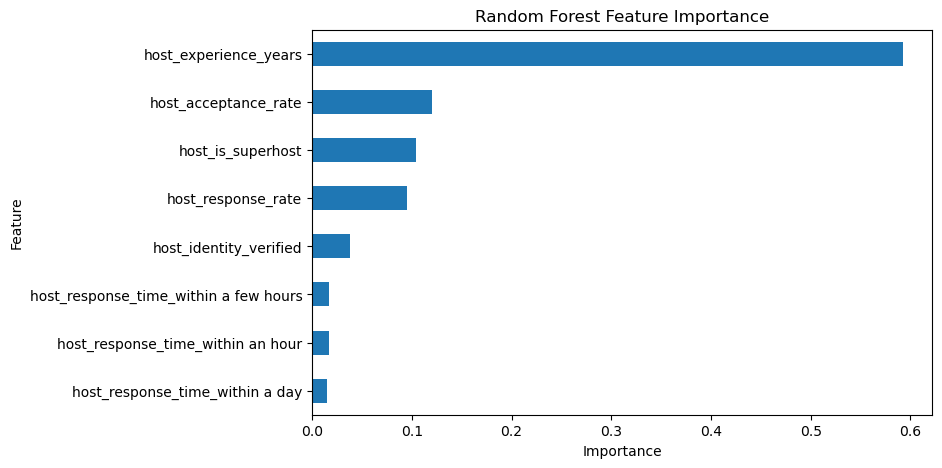

In [39]:
importance.plot.barh(
    x="Feature",
    y="Importance",
    figsize=(8,5),
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

In [40]:
from sklearn.model_selection import train_test_split

from sklearn.inspection import permutation_importance

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [43]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [44]:
perm_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean
}).sort_values(
    by="Importance",
    ascending=False
)

perm_importance

,Feature,Importance
0,host_is_superhost,0.144933
4,host_experience_years,0.122762
1,host_response_rate,0.095358
2,host_acceptance_rate,0.070328
3,host_identity_verified,0.006604
5,host_response_time_within a day,-0.008891
6,host_response_time_within a few hours,-0.009903
7,host_response_time_within an hour,-0.010119


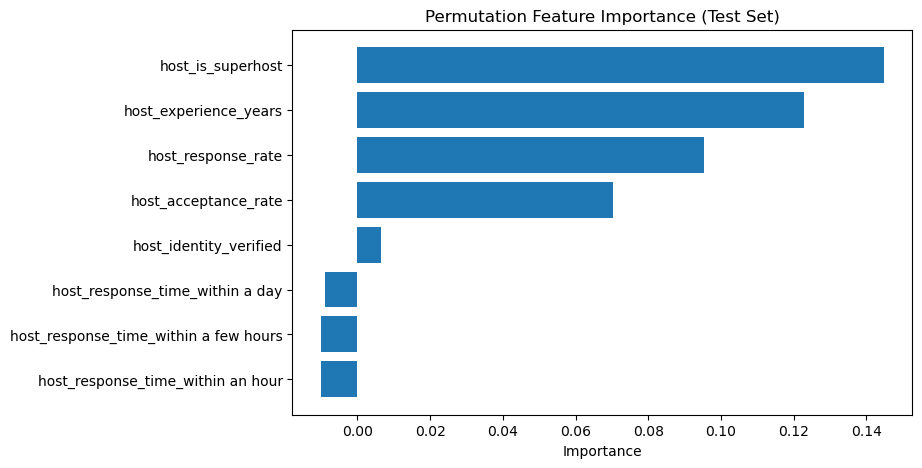

In [45]:
plt.figure(figsize=(8,5))

plt.barh(
    perm_importance["Feature"],
    perm_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Permutation Feature Importance (Test Set)")
plt.xlabel("Importance")

plt.show()

| Variable               | Expected Influence | EDA Score |
| ---------------------- | ------------------ | --------: |
| Host Experience        | High               |  **1.00** |
| Superhost Status       | High               |  **1.00** |
| Host Response Time     | High               |  **1.00** |
| Host Response Rate     | Medium             |  **0.60** |
| Host Identity Verified | Medium             |  **0.60** |
| Host Acceptance Rate   | Low                |  **0.30** |


In [46]:
eda_scores = pd.DataFrame({
    "Variable": [
        "host_experience_years",
        "host_is_superhost",
        "host_response_time",
        "host_response_rate",
        "host_identity_verified",
        "host_acceptance_rate"
    ],
    "EDA_Score": [
        1.0,
        1.0,
        1.0,
        0.6,
        0.6,
        0.3
    ]
})

eda_scores["EDA_Normalized"] = (
    eda_scores["EDA_Score"] /
    eda_scores["EDA_Score"].sum()
)

In [47]:
importance["Variable"] = importance["Feature"]

rf_grouped = (
    importance
    .assign(
        Variable=lambda df: df["Variable"].replace({
            "host_response_time_within an hour": "host_response_time",
            "host_response_time_within a few hours": "host_response_time",
            "host_response_time_within a day": "host_response_time"
        })
    )
    .groupby("Variable", as_index=False)["Importance"]
    .sum()
)

rf_grouped

,Variable,Importance
0,host_acceptance_rate,0.120756
1,host_experience_years,0.592025
2,host_identity_verified,0.038479
3,host_is_superhost,0.104274
4,host_response_rate,0.095272
5,host_response_time,0.049194


In [48]:
perm_importance["Variable"] = perm_importance["Feature"]

perm_grouped = (
    perm_importance
    .assign(
        Variable=lambda df: df["Variable"].replace({
            "host_response_time_within an hour": "host_response_time",
            "host_response_time_within a few hours": "host_response_time",
            "host_response_time_within a day": "host_response_time"
        })
    )
    .groupby("Variable", as_index=False)["Importance"]
    .sum()
)

perm_grouped

,Variable,Importance
0,host_acceptance_rate,0.070328
1,host_experience_years,0.122762
2,host_identity_verified,0.006604
3,host_is_superhost,0.144933
4,host_response_rate,0.095358
5,host_response_time,-0.028912


In [49]:
weights = (
    rf_grouped
    .merge(
        perm_grouped,
        on="Variable",
        suffixes=("_RF", "_Permutation")
    )
    .merge(
        eda_scores[["Variable","EDA_Normalized"]],
        on="Variable"
    )
)

In [50]:
weights["Composite_Score"] = (
      0.30 * weights["Importance_RF"]
    + 0.60 * weights["Importance_Permutation"]
    + 0.10 * weights["EDA_Normalized"]
)

In [51]:
weights["Final_Weight"] = (
    weights["Composite_Score"] /
    weights["Composite_Score"].sum()
) * 100

weights = weights.sort_values(
    "Final_Weight",
    ascending=False
)

weights

,Variable,Importance_RF,Importance_Permutation,EDA_Normalized,Composite_Score,Final_Weight
1,host_experience_years,0.592025,0.122762,0.222222,0.273487,42.293337
3,host_is_superhost,0.104274,0.144933,0.222222,0.140464,21.722027
4,host_response_rate,0.095272,0.095358,0.133333,0.099129,15.329848
0,host_acceptance_rate,0.120756,0.070328,0.066667,0.085090,13.158756
2,host_identity_verified,0.038479,0.006604,0.133333,0.028840,4.459898
5,host_response_time,0.049194,-0.028912,0.222222,0.019633,3.036134


In [52]:
min_exp = listings_fe["host_experience_years"].min()
max_exp = listings_fe["host_experience_years"].max()

listings_fe["host_experience_score"] = (
    (listings_fe["host_experience_years"] - min_exp)
    /
    (max_exp - min_exp)
)

In [53]:
listings_fe["host_response_rate_score"] = (
    listings_fe["host_response_rate"] / 100
)

In [54]:
listings_fe["host_acceptance_rate_score"] = (
    listings_fe["host_acceptance_rate"] / 100
)

In [55]:
listings_fe["superhost_score"] = (
    listings_fe["host_is_superhost"]
    .fillna(False)
    .astype(int)
)

C:\Users\Parv Gupta\AppData\Local\Temp\ipykernel_12568\3950950781.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


In [58]:
listings_fe["identity_score"] = (
    listings_fe["host_identity_verified"]
    .fillna(False)
    .astype(int)
)

C:\Users\Parv Gupta\AppData\Local\Temp\ipykernel_12568\2501485813.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


In [59]:
response_time_mapping = {
    "within an hour": 1.00,
    "within a few hours": 0.75,
    "within a day": 0.50,
    "a few days or more": 0.25
}

listings_fe["response_time_score"] = (
    listings_fe["host_response_time"]
    .map(response_time_mapping)
)

In [60]:
listings_fe["HostTrust"] = (
      0.4229 * listings_fe["host_experience_score"]
    + 0.2172 * listings_fe["superhost_score"]
    + 0.1533 * listings_fe["host_response_rate_score"]
    + 0.1316 * listings_fe["host_acceptance_rate_score"]
    + 0.0446 * listings_fe["identity_score"]
    + 0.0304 * listings_fe["response_time_score"]
) * 100

In [61]:
listings_fe["HostTrust"].describe()

count    134980.000000
mean         28.966405
std          14.235121
min           1.023808
25%          17.592836
50%          27.485791
75%          38.534659
max          71.785668
Name: HostTrust, dtype: float64

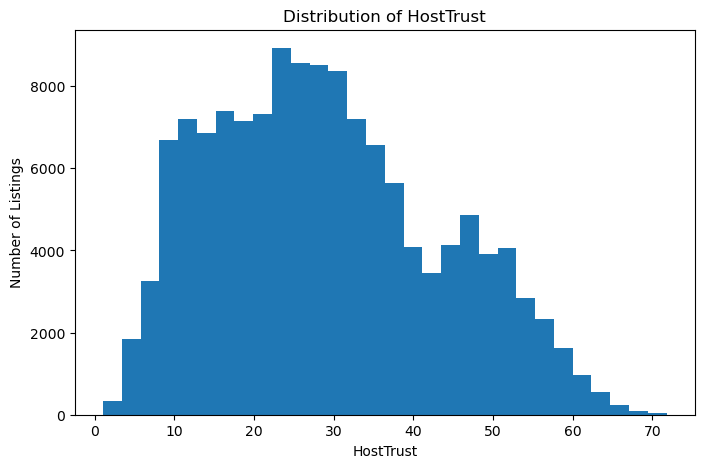

In [62]:
plt.figure(figsize=(8,5))

plt.hist(listings_fe["HostTrust"], bins=30)

plt.title("Distribution of HostTrust")
plt.xlabel("HostTrust")
plt.ylabel("Number of Listings")

plt.show()

In [63]:
host_validation = (
    listings_fe
    .groupby(
        pd.qcut(
            listings_fe["HostTrust"],
            5
        )
    )["review_scores_rating"]
    .agg(["count","mean","median","std"])
)
host_validation

C:\Users\Parv Gupta\AppData\Local\Temp\ipykernel_12568\21904121.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(


,count,mean,median,std
HostTrust,,,,
"(1.0230000000000001, 15.447]",16238,90.098719,94.0,14.534557
"(15.447, 23.839]",19388,92.094956,94.0,10.253304
"(23.839, 31.276]",20845,92.732214,95.0,9.151105
"(31.276, 42.551]",22812,94.719402,97.0,7.148748
"(42.551, 71.786]",24152,96.730374,98.0,4.285948


In [64]:
listings_fe["HostTrust"].head(50)

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
20   NaN
21   NaN
22   NaN
23   NaN
24   NaN
25   NaN
26   NaN
27   NaN
28   NaN
29   NaN
30   NaN
31   NaN
32   NaN
33   NaN
34   NaN
35   NaN
36   NaN
37   NaN
38   NaN
39   NaN
40   NaN
41   NaN
42   NaN
43   NaN
44   NaN
45   NaN
46   NaN
47   NaN
48   NaN
49   NaN
Name: HostTrust, dtype: float64

In [65]:
listings_fe[
    [
        "host_experience_score",
        "host_response_rate_score",
        "host_acceptance_rate_score",
        "superhost_score",
        "identity_score",
        "response_time_score"
    ]
].isna().sum()

host_experience_score            165
host_response_rate_score      128701
host_acceptance_rate_score    113022
superhost_score                    0
identity_score                     0
response_time_score           128701
dtype: int64

In [66]:
listings_fe["HostTrust"].isna().sum()

np.int64(144619)

In [67]:
listings_fe["HostTrust"].notna().sum()

np.int64(134980)

In [68]:
listings_fe["HostTrust"].describe()

count    134980.000000
mean         28.966405
std          14.235121
min           1.023808
25%          17.592836
50%          27.485791
75%          38.534659
max          71.785668
Name: HostTrust, dtype: float64

In [69]:
listings_fe.to_csv("HostTrust_Output.csv", index=False)